# Assignment 1 - Building a Vision Model with Keras

In this assignment, you will build a simple vision model using Keras. The goal is to classify images from the Fashion MNIST dataset, which contains images of clothing items.

You will:
1. Load and inspect the Fashion MNIST dataset.
2. Run a simple baseline model to establish a performance benchmark.
3. Build and evaluate a simple CNN model, choosing appropriate loss and metrics.
4. Design and run controlled experiments on one hyperparameter (e.g., number of filters, kernel size, etc.) and one regularization technique (e.g., dropout, L2 regularization).
5. Analyze the results and visualize the model's performance.

# 1. Loading and Inspecting the Dataset

Fashion MNIST is a dataset of grayscale images of clothing items, with 10 classes. Each image is 28x28 pixels, like the MNIST dataset of handwritten digits. Keras provides a convenient way to load this dataset. 

In this section, you should:

- [ ] Inspect the shapes of the training and test sets to confirm their size and structure.
- [ ] Convert the labels to one-hot encoded format if necessary. (There is a utility function in Keras for this.)
- [ ] Visualize a few images from the dataset to understand what the data looks like.

In [2]:
from tensorflow.keras.datasets import fashion_mnist
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

# Normalize the pixel values to be between 0 and 1
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# Classes in the Fashion MNIST dataset
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat", "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

In [3]:
# Inspect the shapes of the datasets
print(f'X_train shape: {X_train.shape}')
print(f'y_train shape: {y_train.shape}')
print(f'X_test shape: {X_test.shape}')
print(f'y_test shape: {y_test.shape}')

# Convert labels to one-hot encoding
from tensorflow.keras.utils import to_categorical
print(f'Before one-hot encoding: {y_train[0]}')
y_train = to_categorical(y_train, num_classes=10)
y_test = to_categorical(y_test, num_classes=10)
print(f'After one-hot encoding: {y_train[0]}')

X_train shape: (60000, 28, 28)
y_train shape: (60000,)
X_test shape: (10000, 28, 28)
y_test shape: (10000,)
Before one-hot encoding: 9
After one-hot encoding: [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]


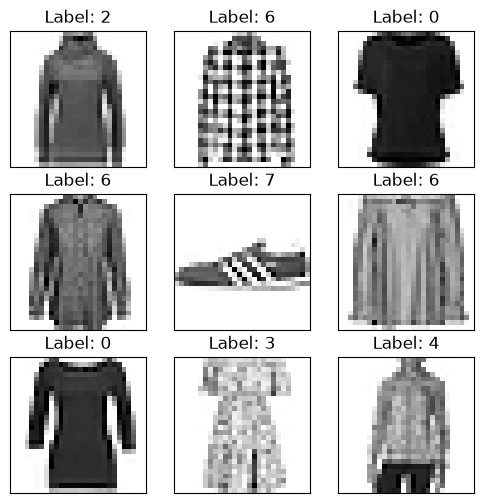

In [4]:
import matplotlib.pyplot as plt
import numpy as np
# Verify the data looks as expected
# Selecting 9 random indices
random_indices = np.random.choice(len(X_train), 9, replace=False)

# Creating a 3x3 grid plot
fig, axes = plt.subplots(3, 3, figsize=(6, 6))

for i, ax in enumerate(axes.flat):
    ax.imshow(X_train[random_indices[i]], cmap=plt.cm.gray_r, interpolation='nearest')
    ax.set_title(f"Label: {np.argmax(y_train[random_indices[i]])}")

    # Removing axis labels
    ax.set_xticks([])
    ax.set_yticks([])

plt.show()

Reflection: Does the data look as expected? How is the quality of the images? Are there any issues with the dataset that you notice?

The data looks expected in general, where a different clothing item has a corresponding label. However, the quality of the images are not optimal, they are low resolution and some classes are visually similar. Some clothing items appear to have different labels, however, even to a human eye they look very similar and could be classified under the same label. 

# 2. Baseline Model

In this section, you will create a linear regression model as a baseline. This model will not use any convolutional layers, but it will help you understand the performance of a simple model on this dataset.
You should:
- [ ] Create a simple linear regression model using Keras.
- [ ] Compile the model with an appropriate loss function and optimizer.
- [ ] Train the model on the training set and evaluate it on the test set.

A linear regression model can be created using the `Sequential` API in Keras. Using a single `Dense` layer with no activation function is equivalent to a simple linear regression model. Make sure that the number of units in the output layer matches the number of classes in the dataset.

Note that for this step, we will need to use `Flatten` to convert the 2D images into 1D vectors before passing them to the model. Put a `Flatten()` layer as the first layer in your model so that the 2D image data can be flattened into 1D vectors.

In [5]:
from keras.models import Sequential
from keras.layers import Dense, Flatten

# Create a simple linear regression model
model = Sequential()
# You can use `model.add(<layer>)` to add layers to the model
model.add(Flatten(input_shape=(28,28,1)))
model.add(Dense(10))  # 10 output classes

# Compile the model using `model.compile()`
model.compile(
    loss='categorical_crossentropy', # Loss function
    optimizer='sgd', # Optimizer
    metrics=['accuracy'] # Metrics to evaluate the model
)
# Train the model with `model.fit()`
model.fit(
    X_train, # Training data
    y_train, # Training labels
    epochs=5, # Number of epochs
    batch_size=32, # Number of samples per batch
    validation_split=0.2 # Use 20% of the data for validation
)
# Evaluate the model with `model.evaluate()`
loss, accuracy = model.evaluate(X_test, y_test)

print(f'Loss:     {loss:.2f}')
print(f'Accuracy: {accuracy*100:.2f}%')

Epoch 1/5


/Users/ziyidai/Desktop/deep_learning/deep-learning-env/lib/python3.11/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 398us/step - accuracy: 0.1259 - loss: 9.5046 - val_accuracy: 0.2152 - val_loss: 8.8313
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 387us/step - accuracy: 0.1007 - loss: 6.3248 - val_accuracy: 0.1005 - val_loss: 5.8299
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 354us/step - accuracy: 0.0999 - loss: 5.9699 - val_accuracy: 0.1005 - val_loss: 5.7423
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 346us/step - accuracy: 0.0999 - loss: 5.8229 - val_accuracy: 0.1005 - val_loss: 5.8160
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 345us/step - accuracy: 0.0999 - loss: 5.8471 - val_accuracy: 0.1005 - val_loss: 5.8241
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 269us/step - accuracy: 0.1000 - loss: 5.9271
Loss:     5.93
Accuracy: 10.00%


Reflection: What is the performance of the baseline model? How does it compare to what you expected? Why do you think the performance is at this level?

The performance of the model is very poor, loss: 5.93 and accuracy:10.00%. This suggests that the model is not learning and not performing better than random chance. I think it's performing poorly becuase by using one Dense layer with no activation, the model ignores the 2D structural information. 

# 3. Building and Evaluating a Simple CNN Model

In this section, you will build a simple Convolutional Neural Network (CNN) model using Keras. A convolutional neural network is a type of deep learning model that is particularly effective for image classification tasks. Unlike the basic neural networks we have built in the labs, CNNs can accept images as input without needing to flatten them into vectors.

You should:
- [ ] Build a simple CNN model with at least one convolutional layer (to learn spatial hierarchies in images) and one fully connected layer (to make predictions).
- [ ] Compile the model with an appropriate loss function and metrics for a multi-class classification problem.
- [ ] Train the model on the training set and evaluate it on the test set.

Convolutional layers are designed to accept inputs with three dimensions: height, width and channels (e.g., RGB for color images). For grayscale images like those in Fashion MNIST, the input shape will be (28, 28, 1).

When you progress from the convolutional layers to the fully connected layers, you will need to flatten the output of the convolutional layers. This can be done using the `Flatten` layer in Keras, which doesn't require any parameters.

In [8]:
from keras.layers import Conv2D

# Reshape the data to include the channel dimension
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

# Create a simple CNN model
model = Sequential()

#Convolutional layer
model.add(Conv2D(3, kernel_size=(3,3), activation= "relu"))

#Flatten before fully connected layers
model.add(Flatten())

model.add(Dense(64, activation='relu'))  # 64 neurons, ReLU activation

# Output layer
model.add(Dense(10, activation='softmax'))  # 10 neurons, softmax activation

model.summary()

# Train the model

model.compile(
    loss='categorical_crossentropy', # Loss function
    optimizer='sgd', # Optimizer
    metrics=['accuracy'] # Metrics to evaluate the model
)

model.fit(
    X_train, # Training data
    y_train, # Training labels
    epochs=5, # Number of epochs
    batch_size=32, # Number of samples per batch
    validation_split=0.2 # Use 20% of the data for validation
)

# Evaluate the model
loss, accuracy = model.evaluate(X_test, y_test)

print(f'Loss:     {loss:.2f}')
print(f'Accuracy: {accuracy*100:.2f}%')

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7493 - loss: 0.7223 - val_accuracy: 0.8098 - val_loss: 0.5280
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8334 - loss: 0.4718 - val_accuracy: 0.8323 - val_loss: 0.4652
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8480 - loss: 0.4258 - val_accuracy: 0.8453 - val_loss: 0.4299
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8582 - loss: 0.3994 - val_accuracy: 0.8529 - val_loss: 0.4109
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8653 - loss: 0.3790 - val_accuracy: 0.8580 - val_loss: 0.3982
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 633us/step - accuracy: 0.8499 - loss: 0.4151
Loss:     0.42
Accuracy: 84.99%


Reflection: Did the CNN model perform better than the baseline model? If so, by how much? What do you think contributed to this improvement?

The CNN model performed significantly better than the baseline model, loss:0.42 and accuracy:84.99% compared to the baseline model. I think the Conv2D layer contributed to this improvement because it learns spatial information in the image instead of flattening the input into vectors. 

# 3. Designing and Running Controlled Experiments

In this section, you will design and run controlled experiments to improve the model's performance. You will focus on one hyperparameter and one regularization technique.
You should:
- [ ] Choose one hyperparameter to experiment with (e.g., number of filters, kernel size, number of layers, etc.) and one regularization technique (e.g., dropout, L2 regularization). For your hyperparameter, you should choose at least three different values to test (but there is no upper limit). For your regularization technique, simply test the presence or absence of the technique.
- [ ] Run experiments by modifying the model architecture or hyperparameters, and evaluate the performance of each model on the test set.
- [ ] Record the results of your experiments, including the test accuracy and any other relevant metrics.
- [ ] Visualize the results of your experiments using plots or tables to compare the performance of different models.

The best way to run your experiments is to create a `for` loop that iterates over a range of values for the hyperparameter you are testing. For example, if you are testing different numbers of filters, you can create a loop that runs the model with 32, 64, and 128 filters. Within the loop, you can compile and train the model, then evaluate it on the test set. After each iteration, you can store the results in a list or a dictionary for later analysis.

Note: It's critical that you re-initialize the model (by creating a new instance of the model) before each experiment. If you don't, the model will retain the weights from the previous experiment, which can lead to misleading results.

In [14]:
# A. Test Hyperparameters
from keras.layers import Conv2D
import pandas as pd
import tensorflow as tf

tf.random.set_seed(42)

# Reshape the data to include the channel dimension
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

def experiments(num_filters):
    # Create a simple CNN model
    model = Sequential()

    #Convolutional layer
    model.add(Conv2D(num_filters, kernel_size=(3,3), activation= "relu"))

    #Flatten before fully connected layers
    model.add(Flatten())

    model.add(Dense(64, activation='relu'))  # 64 neurons, ReLU activation

    # Output layer
    model.add(Dense(10, activation='softmax'))  # 10 neurons, softmax activation

    model.compile(
    loss='categorical_crossentropy', # Loss function
    optimizer='sgd', # Optimizer
    metrics=['accuracy'] # Metrics to evaluate the model    
    )

    return model

filters= [32,64,128]

results= []

for num_filters in filters:
    print(f"Training model with {num_filters} filters")

    model= experiments(
        num_filters=num_filters
    )

    model_training= model.fit(
    X_train, # Training data
    y_train, # Training labels
    epochs=5, # Number of epochs
    batch_size=32, # Number of samples per batch
    validation_split=0.2 # Use 20% of the data for validation
    )

    # Evaluate the model
    exp_loss, exp_accuracy = model.evaluate(X_test, y_test)
 
    results.append({
    "num_filters": num_filters,
    "exp_loss": exp_loss,
    "exp_accuracy": exp_accuracy
})

results_df= pd.DataFrame(results)

Training model with 32 filters
Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7679 - loss: 0.6621 - val_accuracy: 0.8262 - val_loss: 0.4930
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8319 - loss: 0.4734 - val_accuracy: 0.8437 - val_loss: 0.4443
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8484 - loss: 0.4271 - val_accuracy: 0.8529 - val_loss: 0.4174
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8594 - loss: 0.3982 - val_accuracy: 0.8597 - val_loss: 0.3957
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8669 - loss: 0.3761 - val_accuracy: 0.8662 - val_loss: 0.3799
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 937us/step - accuracy: 0.8569 - loss: 0.4032
Training model with 64 filters
Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.7624 - loss: 0.6736 - val_accuracy: 0.8263 - val_loss: 0.4992
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8303 - loss: 0.4768 

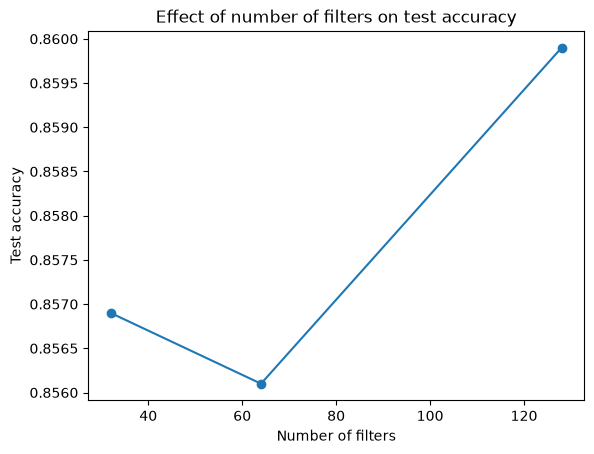

In [ ]:
#A. Continued: plotting accuracy
import matplotlib.pyplot as plt

plt.plot(
    results_df["num_filters"],
    results_df["exp_accuracy"],
    marker="o"
)

plt.xlabel("Number of filters")
plt.ylabel("Test accuracy")
plt.title("Effect of number of filters on test accuracy")
plt.show()

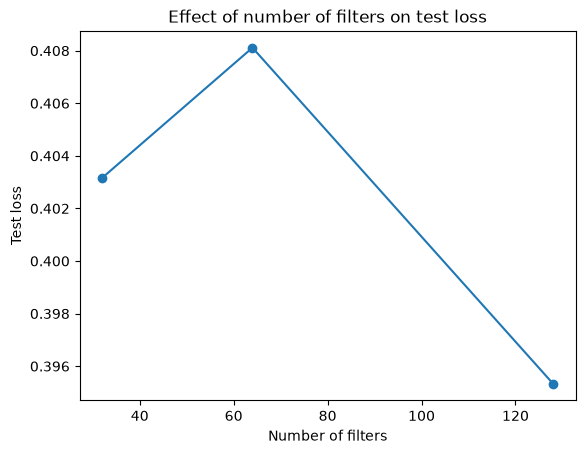

In [18]:
#A. Continued: plotting loss
import matplotlib.pyplot as plt

plt.plot(
    results_df["num_filters"],
    results_df["exp_loss"],
    marker="o"
)

plt.xlabel("Number of filters")
plt.ylabel("Test loss")
plt.title("Effect of number of filters on test loss")
plt.show()

In [22]:
# B. Test presence or absence of regularization
from keras.layers import Conv2D,Dropout
import pandas as pd
import tensorflow as tf

tf.random.set_seed(42)

# Reshape the data to include the channel dimension
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

def regular_experiments(use_dropout):
    # Create a simple CNN model
    model = Sequential()

    #Convolutional layer
    model.add(Conv2D(128, kernel_size=(3,3), activation= "relu"))

    #Flatten before fully connected layers
    model.add(Flatten())

    model.add(Dense(64, activation='relu'))  # 64 neurons, ReLU activation

    if use_dropout:
        model.add(Dropout(0.5))

    # Output layer
    model.add(Dense(10, activation='softmax'))  # 10 neurons, softmax activation

    model.compile(
    loss='categorical_crossentropy', # Loss function
    optimizer='sgd', # Optimizer
    metrics=['accuracy'] # Metrics to evaluate the model    
    )

    return model

dropout_tests= [False, True]

dropout_results= []

for use_dropout in dropout_tests:
    print(f"Training model with {num_filters} filters")

    model= regular_experiments(
        use_dropout=dropout_tests
    )

    model_training= model.fit(
    X_train, # Training data
    y_train, # Training labels
    epochs=5, # Number of epochs
    batch_size=32, # Number of samples per batch
    validation_split=0.2 # Use 20% of the data for validation
    )

    # Evaluate the model
    dropout_loss, dropout_accuracy = model.evaluate(X_test, y_test)
 
    dropout_results.append({
    "dropout": use_dropout,
    "dropout_loss": dropout_loss,
    "dropout_accuracy": dropout_accuracy
})

dropout_results_df= pd.DataFrame(dropout_results)

Training model with 128 filters
Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.6939 - loss: 0.8552 - val_accuracy: 0.8117 - val_loss: 0.5247
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.7750 - loss: 0.6220 - val_accuracy: 0.8295 - val_loss: 0.4748
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.7920 - loss: 0.5729 - val_accuracy: 0.8405 - val_loss: 0.4405
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.8067 - loss: 0.5394 - val_accuracy: 0.8400 - val_loss: 0.4345
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.8141 - loss: 0.5216 - val_accuracy: 0.8439 - val_loss: 0.4124
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8349 - loss: 0.4393
Training model with 128 filters
Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.6989 - loss: 0.8526 - val_accuracy: 0.8058 - val_loss: 0.5277
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.7747 - loss:

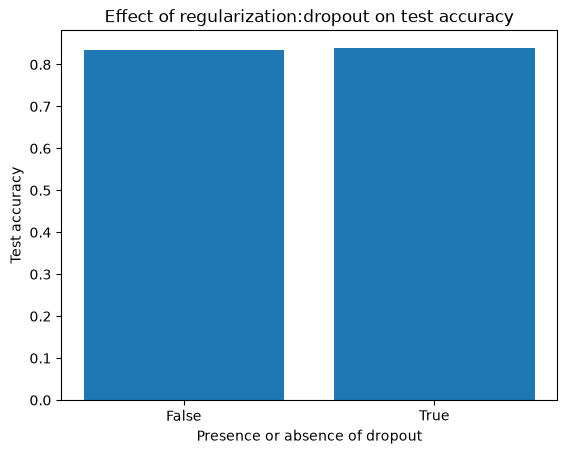

In [28]:
#B. Continued: plotting accuracy
import matplotlib.pyplot as plt

plt.bar(
    dropout_results_df["dropout"].astype(str),
    dropout_results_df["dropout_accuracy"],
)

plt.xlabel("Presence or absence of dropout")
plt.ylabel("Test accuracy")
plt.title("Effect of regularization:dropout on test accuracy")
plt.show()

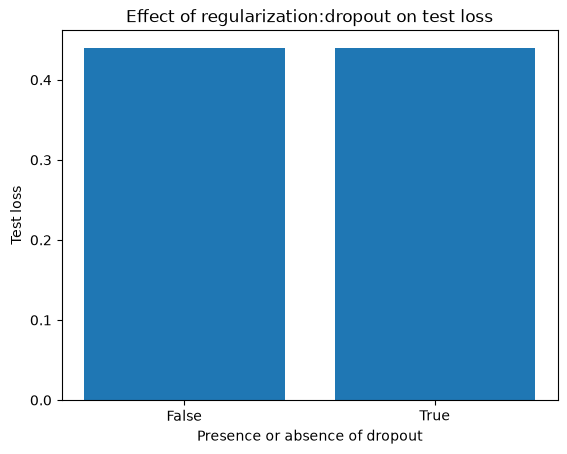

In [29]:
#B. Continued: plotting loss
import matplotlib.pyplot as plt

plt.bar(
    dropout_results_df["dropout"].astype(str),
    dropout_results_df["dropout_loss"],
)

plt.xlabel("Presence or absence of dropout")
plt.ylabel("Test loss")
plt.title("Effect of regularization:dropout on test loss")
plt.show()

Reflection: Report on the performance of the models you tested. Did any of the changes you made improve the model's performance? If so, which ones? What do you think contributed to these improvements? Finally, what combination of hyperparameters and regularization techniques yielded the best performance?

Testing different filter numbers revealed that using a filter number of 128 seem to improve the model's performace slightly, but adding dropout did not improve the model. I think it's because the model is not overfitting, therefore adding dropout did not significantly improve model performance. The increase in numbers of filters did not have a perfectly linear relationship to model performance because model performed worse with 64 filters than 32 filters, but the performance does go up with 128 filters suggesting the use of more filters can be beneficial for the model to learn more features. The combination of using 128 filters with no dropout yielded the best performance. 

# 5. Training Final Model and Evaluation

In this section, you will train the final model using the best hyperparameters and regularization techniques you found in the previous section. You should:
- [ ] Compile the final model with the best hyperparameters and regularization techniques.
- [ ] Train the final model on the training set and evaluate it on the test set.
- [ ] Report the final model's performance on the test set, including accuracy and any other relevant metrics.

In [7]:
from keras.layers import Conv2D

# Reshape the data to include the channel dimension
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

# Create a simple CNN model
model = Sequential()

#Convolutional layer
model.add(Conv2D(128, kernel_size=(3,3), activation= "relu"))

#Flatten before fully connected layers
model.add(Flatten())

model.add(Dense(64, activation='relu'))  # 64 neurons, ReLU activation

# Output layer
model.add(Dense(10, activation='softmax'))  # 10 neurons, softmax activation

model.summary()

# Train the model

model.compile(
    loss='categorical_crossentropy', # Loss function
    optimizer='sgd', # Optimizer
    metrics=['accuracy'] # Metrics to evaluate the model
)

model.fit(
    X_train, # Training data
    y_train, # Training labels
    epochs=5, # Number of epochs
    batch_size=32, # Number of samples per batch
    validation_split=0.2 # Use 20% of the data for validation
)

# Evaluate the model
loss, accuracy = model.evaluate(X_test, y_test)

print(f'Loss:     {loss:.2f}')
print(f'Accuracy: {accuracy*100:.2f}%')

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.7722 - loss: 0.6574 - val_accuracy: 0.8194 - val_loss: 0.5056
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.8329 - loss: 0.4711 - val_accuracy: 0.8491 - val_loss: 0.4322
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.8486 - loss: 0.4236 - val_accuracy: 0.8428 - val_loss: 0.4273
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.8602 - loss: 0.3972 - val_accuracy: 0.8597 - val_loss: 0.3937
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.8668 - loss: 0.3745 - val_accuracy: 0.8634 - val_loss: 0.3841
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8566 - loss: 0.4019
Loss:     0.40
Accuracy: 85.66%


Reflection: How does the final model's performance compare to the baseline and the CNN model? What do you think contributed to the final model's performance? If you had time, what other experiments would you run to further improve the model's performance?
The final model's performance is significantly better than the baseline and slightly better than the CNN model. I think the convolutional layer and the number of filteres contributed to the final model's performance. Additional experiments I may run include adding a pooling layer or adding convolutional layers to further improve the model's performance.

🚨 **Please review our [Assignment Submission Guide](https://github.com/UofT-DSI/onboarding/blob/main/onboarding_documents/submissions.md)** 🚨 for detailed instructions on how to format, branch, and submit your work. Following these guidelines is crucial for your submissions to be evaluated correctly.
### Submission Parameters:
* Submission Due Date: `23:59 PM - 26/10/2025`
* The branch name for your repo should be: `assignment-1`
* What to submit for this assignment:
    * This Jupyter Notebook (assignment_1.ipynb)
    * The Lab 1 notebook (labs/lab_1.ipynb)
    * The Lab 2 notebook (labs/lab_2.ipynb)
    * The Lab 3 notebook (labs/lab_3.ipynb)
* What the pull request link should look like for this assignment: `https://github.com/<your_github_username>/deep_learning/pull/<pr_id>`
* Open a private window in your browser. Copy and paste the link to your pull request into the address bar. Make sure you can see your pull request properly. This helps the technical facilitator and learning support staff review your submission easily.
Checklist:
- [ ] Created a branch with the correct naming convention.
- [ ] Ensured that the repository is public.
- [ ] Reviewed the PR description guidelines and adhered to them.
- [ ] Verify that the link is accessible in a private browser window.
If you encounter any difficulties or have questions, please don't hesitate to reach out to our team via our Slack at `#cohort-7-help-ml`. Our Technical Facilitators and Learning Support staff are here to help you navigate any challenges.